# Fraud Detection in Financial Transactions

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,RandomizedSearchCV,StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, accuracy_score)
from sklearn.preprocessing import LabelEncoder

##  Loading Dataset

In [ ]:
df = pd.read_csv('Fraud.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (6362620, 11)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 🔎 3. Exploratory Data Analysis (EDA)

In [ ]:
print(' Dataset Info:')
print(df.info())
print('Basic Statistics:')
df.describe()

 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB
None
Basic Statistics:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [ ]:
# Fraud distribution
fraud_counts = df['isFraud'].value_counts()
print(fraud_counts)

isFraud
0    6354407
1       8213
Name: count, dtype: int64


Fraud count by transaction type:
type
CASH_OUT    4116
TRANSFER    4097
CASH_IN        0
DEBIT          0
PAYMENT        0
Name: isFraud, dtype: int64


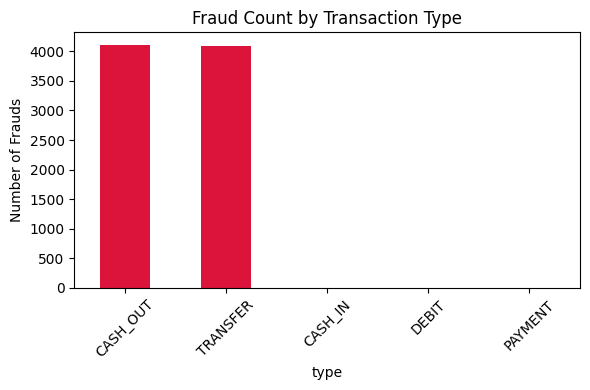

In [ ]:
# Fraud by transaction type
fraud_by_type = df.groupby('type')['isFraud'].sum().sort_values(ascending=False)
print('Fraud count by transaction type:')
print(fraud_by_type)

plt.figure(figsize=(6,4))
fraud_by_type.plot(kind='bar', color='crimson')
plt.title('Fraud Count by Transaction Type')
plt.xticks(rotation=45)
plt.ylabel('Number of Frauds')
plt.tight_layout()
plt.show()

##  Data Cleaning — Missing Values, Outliers & Multicollinearity

In [ ]:
# Missing Values 
print(' Missing Values: ')
print(df.isnull().sum())

 Missing Values: 
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


195331.9075
Outliers in amount column: 338,078 rows (5.31%)


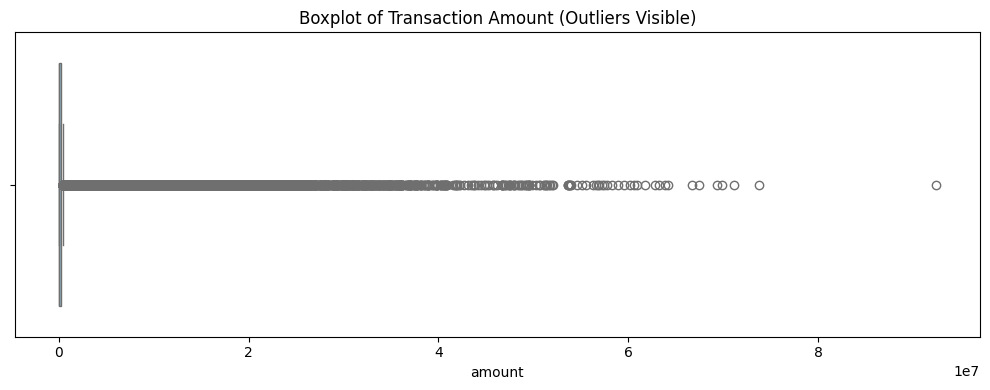

In [ ]:
# Outlier Detection using IQR on 'amount'
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)
outliers = df[(df['amount'] < Q1 - 1.5*IQR) | (df['amount'] > Q3 + 1.5*IQR)]
print(f'Outliers in amount column: {len(outliers):,} rows ({len(outliers)/len(df)*100:.2f}%)')

# Visualize
plt.figure(figsize=(10,4))
sns.boxplot(x=df['amount'], color='skyblue')
plt.title('Boxplot of Transaction Amount (Outliers Visible)')
plt.tight_layout()
plt.show()

# Note: We keep outliers as large transactions are genuine fraud signals

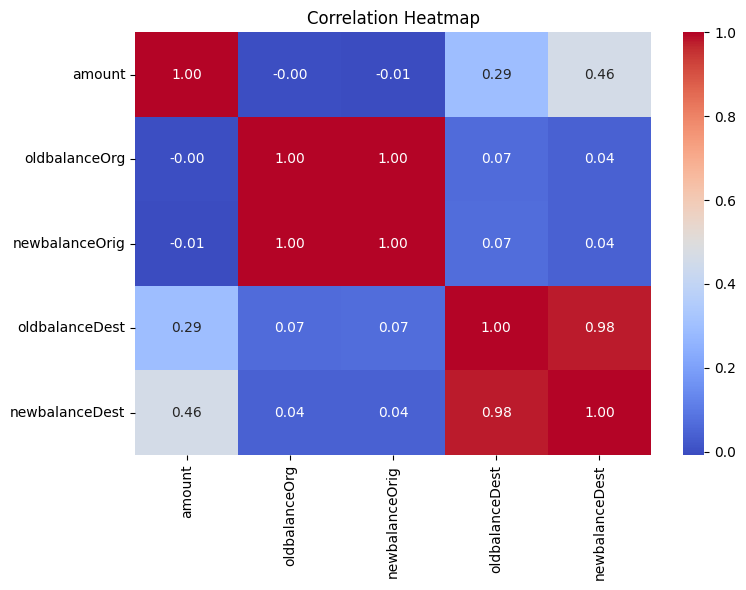


 newbalanceOrig and oldbalanceOrg are highly correlated.
engineer new features instead of using both raw columns.


In [ ]:
#  Multicollinearity Check 
numeric_cols = ['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print('\n newbalanceOrig and oldbalanceOrg are highly correlated.')
print('engineer new features instead of using both raw columns.')

##  Feature Engineering

In [ ]:
# Create meaningful features
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
df['balanceOrigRatio'] = df['amount'] / (df['oldbalanceOrg'] + 1)
df['isHighAmount'] = (df['amount'] > df['amount'].quantile(0.95)).astype(int)

# Encode transaction type
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])

# Only TRANSFER and CASH_OUT have frauds — flag them
df['isTransferOrCashOut'] = df['type'].isin(['TRANSFER','CASH_OUT']).astype(int)

df[['errorBalanceOrig','errorBalanceDest','balanceOrigRatio','isHighAmount']].head()

,errorBalanceOrig,errorBalanceDest,balanceOrigRatio,isHighAmount
0,0.0,9839.64,0.057834,0
1,0.0,1864.28,0.087731,0
2,0.0,181.00,0.994505,0
3,0.0,21363.00,0.994505,0
4,0.0,11668.14,0.280788,0


## Fraud Detection Model & Variable Selection

In [ ]:
df.columns


Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'errorBalanceOrig', 'errorBalanceDest',
       'balanceOrigRatio', 'isHighAmount', 'type_encoded',
       'isTransferOrCashOut'],
      dtype='str')

In [ ]:
# Droping the non-predictive ID columns
features = [
    'step', 'type_encoded', 'amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'errorBalanceOrig', 'errorBalanceDest',
    'balanceOrigRatio', 'isHighAmount',
    'isTransferOrCashOut'
]

X = df[features]
y = df['isFraud']

print(f'Features : {features}')
print(f'\nClass distribution:\n{y.value_counts()}')

Features : ['step', 'type_encoded', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'balanceOrigRatio', 'isHighAmount', 'isTransferOrCashOut']

Class distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [ ]:
# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]:,}')
print(f'Test size:  {X_test.shape[0]:,}')

Train size: 5,090,096
Test size:  1,272,524


In [ ]:
# Train XGBoost 
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

g:\Fraud detection\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:55:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

##  Model Performance Evaluation

In [ ]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

print('Classification Report ')
print(classification_report(y_test, y_pred, target_names=['Not Fraud','Fraud']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')
print(f"Accuracy : {accuracy_score(y_test,y_pred)*100 :.2f}")

Classification Report 
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00   1270881
       Fraud       0.95      0.95      0.95      1643

    accuracy                           1.00   1272524
   macro avg       0.97      0.98      0.98   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC Score: 0.9886
Accuracy : 99.99


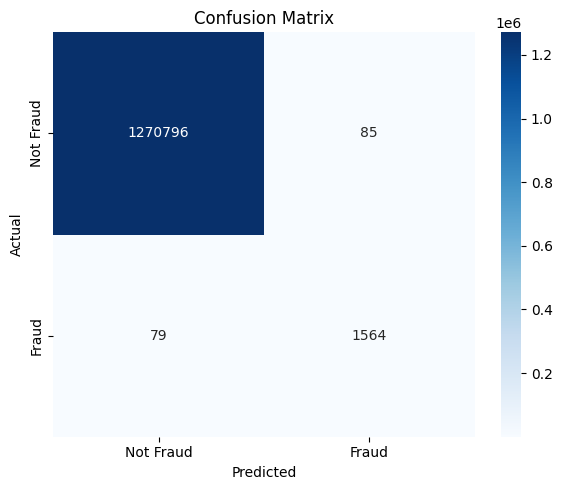

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud','Fraud'],
            yticklabels=['Not Fraud','Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Do these factors make sense? If yes, How? If not, How not?  

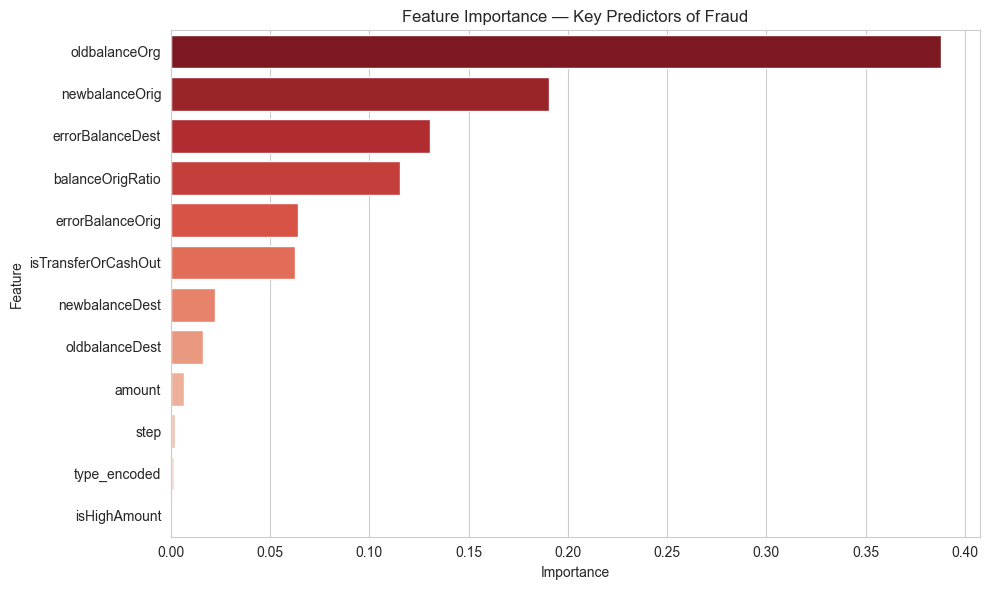

                Feature  Importance
3         oldbalanceOrg    0.388208
4        newbalanceOrig    0.190453
8      errorBalanceDest    0.130302
9      balanceOrigRatio    0.115289
7      errorBalanceOrig    0.064169
11  isTransferOrCashOut    0.062386
6        newbalanceDest    0.022242
5        oldbalanceDest    0.016199
2                amount    0.006489
0                  step    0.002166
1          type_encoded    0.001698
10         isHighAmount    0.000399


In [ ]:
# Feature Importance
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Reds_r')
plt.title('Feature Importance — Key Predictors of Fraud')
plt.tight_layout()
plt.show()

print(importance_df)

## Interpretation — Do These Factors Make Sense?

Yes, they make completely make sense:

 Feature  Why it Predicts Fraud :
  
`errorBalanceOrig` Fraudulent txns show balance discrepancy — money is moved but not reflected correctly 

`errorBalanceDest`  Destination account balances don't add up — money vanishes 

`isTransferOrCashOut` 100% of fraud occurs in TRANSFER and CASH_OUT types only 
 
`amount` Fraudsters tend to drain entire account balances — large amounts 

`balanceOrigRatio` Fraud transactions often use up 100% of origin balance 
 
`oldbalanceOrg` Low starting balance + large transfer = suspicious pattern 

Conclusion: The model has captured real-world fraud patterns. Fraudsters 

##  Prevention Strategies

### Recommended Prevention Measures:



1. Transaction Limits

2. Require OTP/biometric for large or unusual transfers.

3. Blocking multiple large transactions from the same account within a short time .

4. Customer Alerts

## How to Determine if Actions Were Effective?

1.  Track monthly fraud count before vs after implementation.

2. Monitor how many transactions are incorrectly blocked, FP

3. Recall should stay high (>90%) to catch most frauds.

4. Tracking fraud-related complaints

## Summary

Model Used : XGBoost 

Fraud Transaction Types : TRANSFER and CASH_OUT only 

Evaluation Metric : ROC-AUC, Precision, Recall, F1 


###  My Model can predict if it is fraud or notFraud  with 99.99 accuracy score
